# BHX

BHX 데이터셋은 3D mask 기반 데이터셋과 달리, **series / SOP instance 단위의 bounding box annotation CSV**를 중심으로 분석한다.

이 노트북의 목표는 다음과 같다.
- CSV 3종의 구조와 포함 관계를 정리한다.
- labelName / labelType 분포를 확인한다.
- bbox 크기, 비율, 분포를 요약한다.
- downstream 학습에 사용할 수 있도록 데이터셋 단위 통계를 정리한다.


In [1]:
from __future__ import annotations

import ast
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_columns", 50)

DATA_ROOT = Path("/home/jovyan/aicon-gamma-datavol-1/hjgoh/ich-vlm/data/bhx")
NOTEBOOK_ROOT = Path("/home/jovyan/aicon-gamma-datavol-1/hjgoh/ich-vlm/notebook")

CSV_1 = DATA_ROOT / "1_Initial_Manual_Labeling.csv"
CSV_2 = DATA_ROOT / "2_Extrapolation_to_All_Series.csv"
CSV_3 = DATA_ROOT / "3_Extrapolation_to_Selected_Series.csv"
EXAMPLE_IMG = DATA_ROOT / "example_annotated_images.png"

CSV_PATHS = {
    "initial_manual": CSV_1,
    "all_series": CSV_2,
    "selected_series": CSV_3,
}

In [2]:
def load_bhx_csv(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, encoding="utf-8-sig")
    if "Unnamed: 0" in df.columns:
        df = df.drop(columns=["Unnamed: 0"])
    return df


def parse_bbox(value: str) -> dict[str, float]:
    data = ast.literal_eval(value)
    return {
        "x": float(data["x"]),
        "y": float(data["y"]),
        "width": float(data["width"]),
        "height": float(data["height"]),
    }


def enrich_bbox(df: pd.DataFrame) -> pd.DataFrame:
    bbox_df = df["data"].apply(parse_bbox).apply(pd.Series)
    out = pd.concat([df.reset_index(drop=True), bbox_df], axis=1)
    out["area"] = out["width"] * out["height"]
    out["aspect_ratio"] = out["width"] / out["height"]
    return out


dfs = {name: load_bhx_csv(path) for name, path in CSV_PATHS.items()}
for name, df in dfs.items():
    print(name, df.shape)
    display(df.head(3))


initial_manual (6283, 6)


,SOPInstanceUID,SeriesInstanceUID,StudyInstanceUID,data,labelName,labelType
0,1.2.276.0.7230010.3.1.4.296485376.1.1521713089.1721949,1.2.276.0.7230010.3.1.3.296485376.1.1521713089.1721932,1.2.276.0.7230010.3.1.2.296485376.1.1521713088.1721651,"{'x': 236.16402999999997, 'y': 151.01577, 'width': 50.876979999999996, 'height': 62.99052}",Intraventricular,handDrawn
1,1.2.276.0.7230010.3.1.4.296485376.1.1521713089.1721953,1.2.276.0.7230010.3.1.3.296485376.1.1521713089.1721932,1.2.276.0.7230010.3.1.2.296485376.1.1521713088.1721651,"{'x': 232.93374, 'y': 156.66877, 'width': 57.33755, 'height': 48.45427}",Intraventricular,handDrawn
2,1.2.276.0.7230010.3.1.4.296485376.1.1521713089.1721959,1.2.276.0.7230010.3.1.3.296485376.1.1521713089.1721932,1.2.276.0.7230010.3.1.2.296485376.1.1521713088.1721651,"{'x': 230.51106000000001, 'y': 147.78548999999998, 'width': 57.33752, 'height': 54.10725}",Intraventricular,handDrawn


all_series (39668, 6)


,SOPInstanceUID,SeriesInstanceUID,StudyInstanceUID,data,labelName,labelType
0,1.2.276.0.7230010.3.1.4.296485376.1.1521713091.1722412,1.2.276.0.7230010.3.1.3.296485376.1.1521713090.1722057,1.2.276.0.7230010.3.1.2.296485376.1.1521713088.1721651,"{'x': 320.95899, 'y': 235.81072999999998, 'width': 30.68771, 'height': 52.4921}",Intraventricular,selectedThinSlices
1,1.2.276.0.7230010.3.1.4.296485376.1.1521713091.1722416,1.2.276.0.7230010.3.1.3.296485376.1.1521713090.1722057,1.2.276.0.7230010.3.1.2.296485376.1.1521713088.1721651,"{'x': 320.95899, 'y': 235.81072999999998, 'width': 30.68771, 'height': 52.4921}",Intraventricular,selectedThinSlices
2,1.2.276.0.7230010.3.1.4.296485376.1.1521713091.1722372,1.2.276.0.7230010.3.1.3.296485376.1.1521713090.1722057,1.2.276.0.7230010.3.1.2.296485376.1.1521713088.1721651,"{'x': 320.95899, 'y': 235.81072999999998, 'width': 30.68771, 'height': 52.4921}",Intraventricular,selectedThinSlices


selected_series (27203, 6)


,SOPInstanceUID,SeriesInstanceUID,StudyInstanceUID,data,labelName,labelType
0,1.2.276.0.7230010.3.1.4.296485376.1.1521713091.1722412,1.2.276.0.7230010.3.1.3.296485376.1.1521713090.1722057,1.2.276.0.7230010.3.1.2.296485376.1.1521713088.1721651,"{'x': 320.95899, 'y': 235.81072999999998, 'width': 30.68771, 'height': 52.4921}",Intraventricular,selectedThinSlices
1,1.2.276.0.7230010.3.1.4.296485376.1.1521713091.1722416,1.2.276.0.7230010.3.1.3.296485376.1.1521713090.1722057,1.2.276.0.7230010.3.1.2.296485376.1.1521713088.1721651,"{'x': 320.95899, 'y': 235.81072999999998, 'width': 30.68771, 'height': 52.4921}",Intraventricular,selectedThinSlices
2,1.2.276.0.7230010.3.1.4.296485376.1.1521713091.1722372,1.2.276.0.7230010.3.1.3.296485376.1.1521713090.1722057,1.2.276.0.7230010.3.1.2.296485376.1.1521713088.1721651,"{'x': 320.95899, 'y': 235.81072999999998, 'width': 30.68771, 'height': 52.4921}",Intraventricular,selectedThinSlices


In [3]:
# 다른 노트북(MBH-Seg25 등)과 이름/색을 통일. Chronic은 표준 5클래스에 없는 BHX 고유 카테고리라 그대로 유지.
class_names = {1: "EDH", 2: "IPH", 3: "IVH", 4: "SAH", 5: "SDH"}
class_colors = {
    1: (198, 68, 66),    # EDH
    2: (76, 71, 199),    # IPH
    3: (171, 43, 171),   # IVH
    4: (168, 181, 112),  # SAH
    5: (4, 136, 133),    # SDH
}

BHX_LABEL_TO_ABBR = {
    "Epidural": "EDH",
    "Intraparenchymal": "IPH",
    "Intraventricular": "IVH",
    "Subarachnoid": "SAH",
    "Subdural": "SDH",
    "Chronic": "Chronic",  # 그대로 유지 (표준 5클래스에 없는 별도 카테고리)
}

ABBR_COLOR_HEX = {class_names[cid]: "#%02x%02x%02x" % rgb for cid, rgb in class_colors.items()}
ABBR_COLOR_HEX["Chronic"] = "#ff8c00"  # 표준 팔레트에 없는 카테고리라 별도 색 지정

# 이후 모든 분석은 3번 CSV(selected_series: handDrawn + selectedThinSlices, 'other' 제외)만 기준으로 진행
df = dfs["selected_series"].copy()
df["abbr"] = df["labelName"].map(BHX_LABEL_TO_ABBR)

print(f"분석 기준: selected_series (3_Extrapolation_to_Selected_Series.csv)")
print(f"rows={len(df)}, studies={df['StudyInstanceUID'].nunique()}, "
      f"series={df['SeriesInstanceUID'].nunique()}, sop={df['SOPInstanceUID'].nunique()}")
print("abbr 분포:\n", df["abbr"].value_counts())

분석 기준: selected_series (3_Extrapolation_to_Selected_Series.csv)
rows=27203, studies=226, series=389, sop=15979
abbr 분포:
 abbr
SDH        7904
SAH        7596
IPH        5264
Chronic    3672
IVH        2219
EDH         548
Name: count, dtype: int64


## 1. Basic Info

selected_series(3번 CSV) 기준으로 규모, 고유 study / series / SOP 수를 확인한다.

In [4]:
summary_df = pd.DataFrame([{
    "dataset": "selected_series",
    "rows": len(df),
    "studies": df["StudyInstanceUID"].nunique(),
    "series": df["SeriesInstanceUID"].nunique(),
    "sop": df["SOPInstanceUID"].nunique(),
    "label_types": ", ".join(sorted(df["labelType"].dropna().unique())),
    "labels": ", ".join(sorted(df["abbr"].dropna().unique())),
}])
display(summary_df)

,dataset,rows,studies,series,sop,label_types,labels
0,selected_series,27203,226,389,15979,"handDrawn, selectedThinSlices","Chronic, EDH, IPH, IVH, SAH, SDH"


### 1.1 Cross-dataset Comparison Table 채우기 (pilot)

MBH-Seg25 / SNU HE-01과 같은 형식의 비교표에 들어갈 BHX 행 값을 실제 데이터(CSV3 + CQ500 DICOM)에서 계산한다.

In [5]:
import SimpleITK as sitk

CQ500_EXTRACTED = Path("/home/jovyan/aicon-gamma-datavol-1/hjgoh/ich-vlm/data/CQ500/extracted")


def get_dicom_size(study_dir: Path) -> tuple[int, int] | None:
    dcm_files = list(study_dir.rglob("*.dcm"))
    if not dcm_files:
        return None
    reader = sitk.ImageFileReader()
    reader.SetFileName(str(dcm_files[0]))
    reader.ReadImageInformation()
    return reader.GetSize()[:2]


# 실제 CQ500 dcm 파일 하나를 읽어 image size 검증 (여러 study를 표본 확인)
study_dirs = sorted(p for p in CQ500_EXTRACTED.iterdir() if p.is_dir())
sample_sizes = {get_dicom_size(d) for d in study_dirs[:10]}
print("표본 10개 study의 DICOM size 종류:", sample_sizes)
sample_size = next(iter(sample_sizes))

bhx_row = {
    "Class": df["abbr"].nunique(),                              # EDH/IPH/IVH/SAH/SDH/Chronic
    "In/Ex": "Ex",                                               # CQ500 기반 외부 공개 데이터셋
    "Samples": df["StudyInstanceUID"].nunique(),                 # study(스캔) 수
    "Slice": df["SOPInstanceUID"].nunique(),                     # annotation이 달린 slice(SOP instance) 수
    "Image": "DICOM(.dcm) — CQ500 원본",
    "Mask": "없음 (bbox만 존재, pixel-level mask 아님)",
    "Size": f"{sample_size[0]}*{sample_size[1]}" if sample_size else "확인 필요",
    "Type": "2D (slice별 bbox)",
    "Label source": "Bounding box (handDrawn + selectedThinSlices)",
    "Train": "-",                                                # 공식 train/test split 없음
    "Test": f"{df['StudyInstanceUID'].nunique()} (전체 external)",
}

display(pd.DataFrame([bhx_row], index=["BHX"]).T)
print("\nabbr 목록:", sorted(df["abbr"].unique()))
print("(참고: 'Chronic'은 표준 5클래스 체계에 없는 BHX 고유 카테고리라 그대로 유지함)")

표본 10개 study의 DICOM size 종류: {(512, 512)}


,BHX
Class,6
In/Ex,Ex
Samples,226
Slice,15979
Image,DICOM(.dcm) — CQ500 원본
Mask,"없음 (bbox만 존재, pixel-level mask 아님)"
Size,512*512
Type,2D (slice별 bbox)
Label source,Bounding box (handDrawn + selectedThinSlices)
Train,-



abbr 목록: ['Chronic', 'EDH', 'IPH', 'IVH', 'SAH', 'SDH']
(참고: 'Chronic'은 표준 5클래스 체계에 없는 BHX 고유 카테고리라 그대로 유지함)


## 2. Label Distribution

selected_series(3번 CSV) 기준으로 class imbalance, labelType 분포를 확인한다.

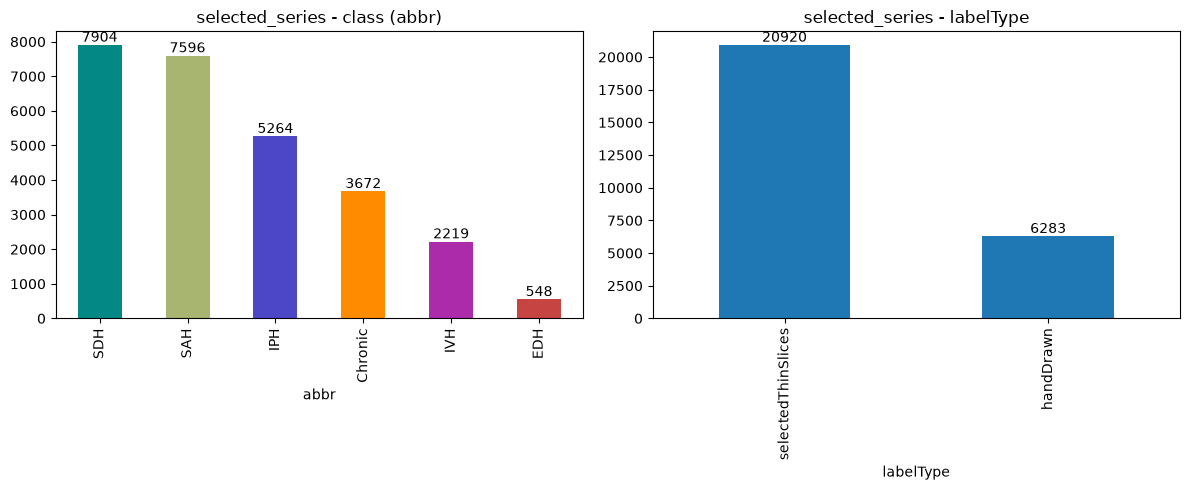

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

abbr_counts = df["abbr"].value_counts().sort_values(ascending=False)
type_counts = df["labelType"].value_counts().sort_values(ascending=False)

bar_colors = [ABBR_COLOR_HEX.get(a, "gray") for a in abbr_counts.index]
abbr_counts.plot(kind="bar", ax=axes[0], title="selected_series - class (abbr)", color=bar_colors)
type_counts.plot(kind="bar", ax=axes[1], title="selected_series - labelType")

for ax in axes:
    for container in ax.containers:
        ax.bar_label(container, fmt="%d")

plt.tight_layout()
plt.show()

## 3. BBox Geometry

selected_series(3번 CSV) 기준으로 bbox의 width, height, area, aspect ratio 분포를 확인한다.

,width,height,area,aspect_ratio
count,27203.000000,27203.000000,27203.000000,27203.000000
mean,76.264366,123.672317,11949.513507,0.753169
std,49.826342,83.000366,14470.840571,0.439603
min,7.943590,10.110020,120.464622,0.059480
1%,15.887160,17.977540,362.004805,0.184314
5%,20.995260,28.044950,739.979284,0.260000
50%,64.719100,100.116260,6244.059565,0.646288
95%,177.000000,292.468270,41646.719452,1.638889
99%,256.361080,341.000000,71661.315150,2.224000
max,303.460660,420.991550,91173.959839,4.000001


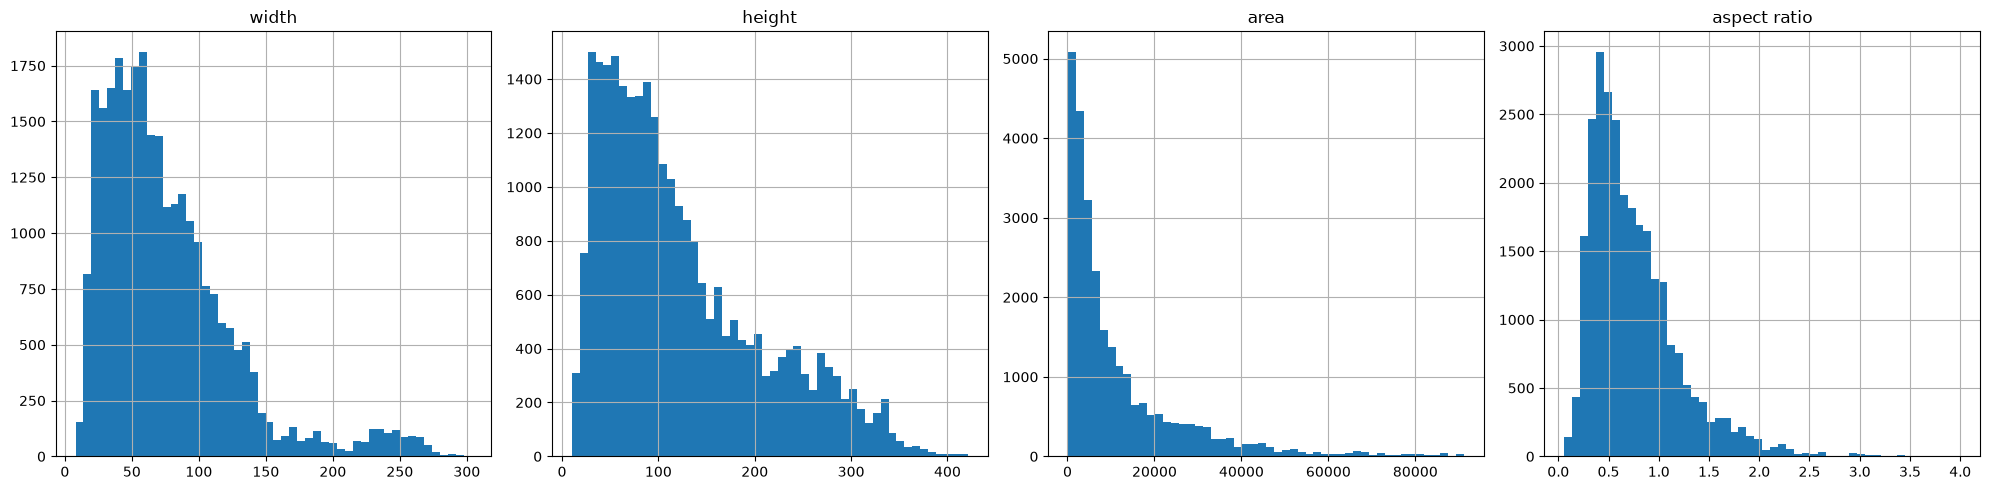

In [7]:
bbox_df = enrich_bbox(df)

display(bbox_df[["width", "height", "area", "aspect_ratio"]].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]))

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
bbox_df["width"].hist(ax=axes[0], bins=50)
axes[0].set_title("width")
bbox_df["height"].hist(ax=axes[1], bins=50)
axes[1].set_title("height")
bbox_df["area"].hist(ax=axes[2], bins=50)
axes[2].set_title("area")
bbox_df["aspect_ratio"].replace([np.inf, -np.inf], np.nan).dropna().hist(ax=axes[3], bins=50)
axes[3].set_title("aspect ratio")

plt.tight_layout()
plt.show()

## 4. Series / Study Unit Analysis

selected_series(3번 CSV) 기준으로 study당 series 개수, series당 annotation이 얼마나 몰려 있는지 확인한다.

study 당 series 개수 요약


count    226.000000
mean       1.721239
std        0.513974
min        1.000000
25%        1.000000
50%        2.000000
75%        2.000000
max        4.000000
Name: SeriesInstanceUID, dtype: float64

series 당 annotation 개수 요약


count    389.000000
mean      69.930591
std       98.511645
min        1.000000
25%       10.000000
50%       28.000000
75%       77.000000
max      596.000000
dtype: float64

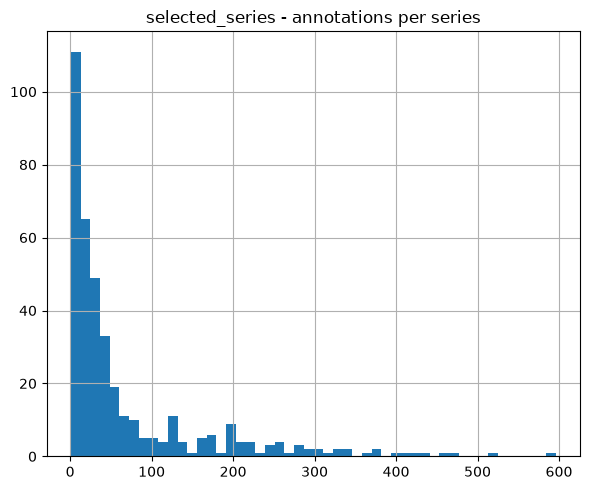

In [8]:
study_series = df.groupby("StudyInstanceUID")["SeriesInstanceUID"].nunique().sort_values(ascending=False)
series_counts = df.groupby("SeriesInstanceUID").size().sort_values(ascending=False)

print("study 당 series 개수 요약")
display(study_series.describe())
print("series 당 annotation 개수 요약")
display(series_counts.describe())

fig, ax = plt.subplots(figsize=(6, 5))
series_counts.hist(ax=ax, bins=50)
ax.set_title("selected_series - annotations per series")
plt.tight_layout()
plt.show()

## 5. Visualization

In [9]:
### 5.1 실제 CQ500 DICOM 위에 BHX bbox 오버레이 — 샘플링 로직

def build_study_uid_to_dir(extracted_root: Path) -> dict[str, Path]:
    """extracted 폴더의 study 폴더마다 dcm 하나만 읽어 StudyInstanceUID -> 폴더 경로 매핑."""
    mapping = {}
    for study_dir in sorted(p for p in extracted_root.iterdir() if p.is_dir()):
        dcm_files = list(study_dir.rglob("*.dcm"))
        if not dcm_files:
            continue
        reader = sitk.ImageFileReader()
        reader.SetFileName(str(dcm_files[0]))
        reader.ReadImageInformation()
        uid = reader.GetMetaData("0020|000d").strip()
        mapping[uid] = study_dir
    return mapping


study_uid_to_dir = build_study_uid_to_dir(CQ500_EXTRACTED)
print(f"매핑된 study 수: {len(study_uid_to_dir)} / BHX(selected_series) study 수: {df['StudyInstanceUID'].nunique()}")

매핑된 study 수: 226 / BHX(selected_series) study 수: 226


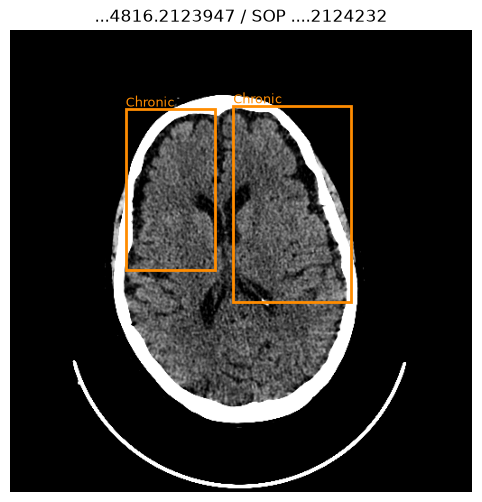

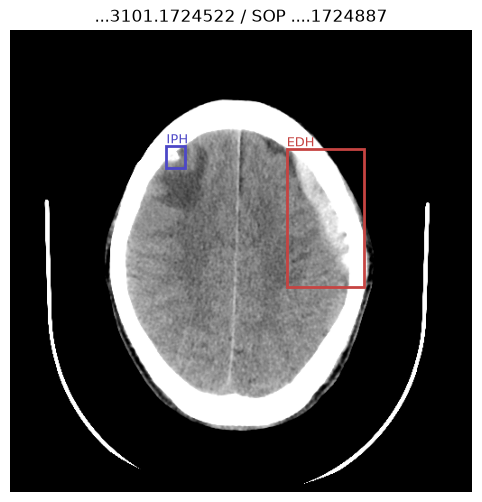

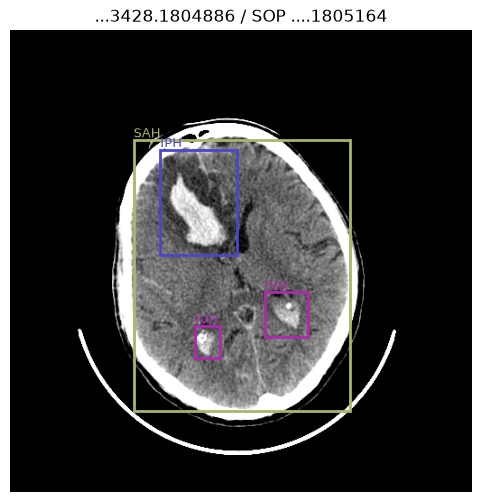

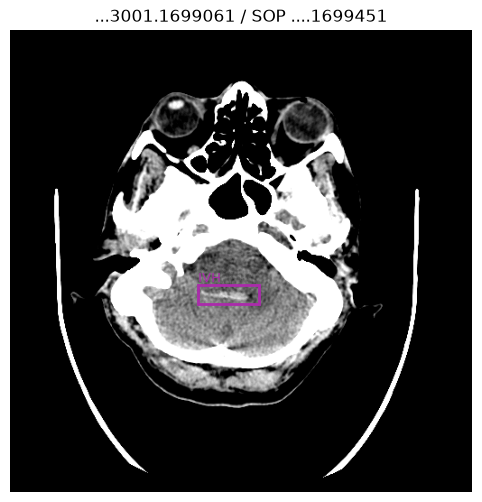

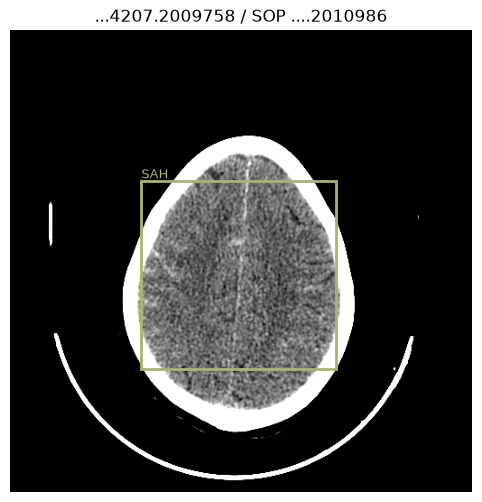

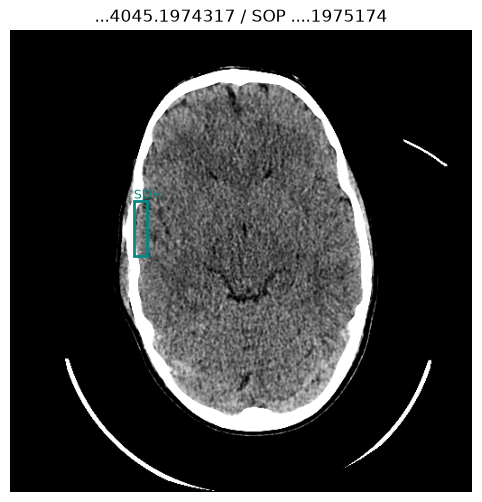

In [10]:
_sop_index_cache: dict[str, dict[str, Path]] = {}


def find_dicom_by_sop(study_dir: Path, sop_uid: str) -> Path | None:
    """study 폴더 안 dcm들을 SOPInstanceUID로 인덱싱(스터디당 1회)해서 찾는다."""
    key = str(study_dir)
    if key not in _sop_index_cache:
        idx = {}
        for f in study_dir.rglob("*.dcm"):
            reader = sitk.ImageFileReader()
            reader.SetFileName(str(f))
            reader.ReadImageInformation()
            idx[reader.GetMetaData("0008|0018").strip()] = f
        _sop_index_cache[key] = idx
    return _sop_index_cache[key].get(sop_uid)


def apply_window(slice_hu, window_level=40, window_width=80):
    lo, hi = window_level - window_width / 2, window_level + window_width / 2
    return (np.clip(slice_hu, lo, hi) - lo) / (hi - lo)


def show_bhx_sample(row):
    """df(selected_series)의 한 행(annotation)을 실제 CQ500 슬라이스 위에 그려서 확인.
    같은 슬라이스의 다른 annotation도 같이 표시. 색/이름은 class_names·class_colors(+Chronic)로 통일."""
    study_dir = study_uid_to_dir.get(row["StudyInstanceUID"])
    if study_dir is None:
        print("study를 찾을 수 없음:", row["StudyInstanceUID"])
        return
    dcm_path = find_dicom_by_sop(study_dir, row["SOPInstanceUID"])
    if dcm_path is None:
        print("SOPInstanceUID 매칭 실패:", row["SOPInstanceUID"])
        return

    arr = sitk.GetArrayFromImage(sitk.ReadImage(str(dcm_path)))[0].astype(np.float32)
    windowed = apply_window(arr)

    same_slice = df[
        (df["StudyInstanceUID"] == row["StudyInstanceUID"])
        & (df["SOPInstanceUID"] == row["SOPInstanceUID"])
    ]

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(windowed, cmap="gray", vmin=0, vmax=1)
    for _, r in same_slice.iterrows():
        bbox = parse_bbox(r["data"])
        color = ABBR_COLOR_HEX.get(r["abbr"], "lime")
        ax.add_patch(plt.Rectangle(
            (bbox["x"], bbox["y"]), bbox["width"], bbox["height"],
            fill=False, edgecolor=color, linewidth=2,
        ))
        ax.text(bbox["x"], bbox["y"] - 3, r["abbr"], color=color, fontsize=9)
    ax.set_title(f"...{row['StudyInstanceUID'][-12:]} / SOP ...{row['SOPInstanceUID'][-8:]}")
    ax.axis("off")
    plt.show()


# 클래스별로 샘플 하나씩 뽑아서 확인 (study당 dcm 인덱싱 때문에 첫 조회는 시간이 좀 걸림)
samples = df.groupby("abbr", group_keys=False).apply(lambda g: g.sample(1, random_state=0))
for _, row in samples.iterrows():
    show_bhx_sample(row)

### 5.2 SAH 세분화(한 슬라이스 다중 bbox) vs SDH 대형 단일 bbox 사례

SAH: 한 슬라이스에 bbox가 여러 개로 세분화된 사례 (상위 5개)


,StudyInstanceUID,SOPInstanceUID,n_boxes
2641,1.2.276.0.7230010.3.1.2.296485376.1.1521714077.1982325,1.2.276.0.7230010.3.1.4.296485376.1.1521714077.1982483,4
3984,1.2.276.0.7230010.3.1.2.296485376.1.1521714242.2017580,1.2.276.0.7230010.3.1.4.296485376.1.1521714249.2019406,4
2645,1.2.276.0.7230010.3.1.2.296485376.1.1521714077.1982325,1.2.276.0.7230010.3.1.4.296485376.1.1521714077.1982491,4
2644,1.2.276.0.7230010.3.1.2.296485376.1.1521714077.1982325,1.2.276.0.7230010.3.1.4.296485376.1.1521714077.1982489,4
2090,1.2.276.0.7230010.3.1.2.296485376.1.1521713681.1873994,1.2.276.0.7230010.3.1.4.296485376.1.1521713681.1874023,4



SDH: 슬라이스당 bbox 1개인데 크게(면적 상위) 그려진 사례 (상위 5개)


,StudyInstanceUID,SOPInstanceUID,n_boxes,area
2713,1.2.276.0.7230010.3.1.2.296485376.1.1521713986.1959201,1.2.276.0.7230010.3.1.4.296485376.1.1521713993.1961067,1,54730.549773
2714,1.2.276.0.7230010.3.1.2.296485376.1.1521713986.1959201,1.2.276.0.7230010.3.1.4.296485376.1.1521713993.1961069,1,54730.549773
2721,1.2.276.0.7230010.3.1.2.296485376.1.1521713986.1959201,1.2.276.0.7230010.3.1.4.296485376.1.1521713993.1961083,1,54730.549773
2685,1.2.276.0.7230010.3.1.2.296485376.1.1521713986.1959201,1.2.276.0.7230010.3.1.4.296485376.1.1521713993.1961011,1,54730.549773
2801,1.2.276.0.7230010.3.1.2.296485376.1.1521713986.1959201,1.2.276.0.7230010.3.1.4.296485376.1.1521713995.1961362,1,54730.549773



SAH 세분화 예시 -> study=...4077.1982325, sop=....1982483, n_boxes=4
SDH 대형 단일 bbox 예시 -> study=...3986.1959201, sop=....1961067, area=54731


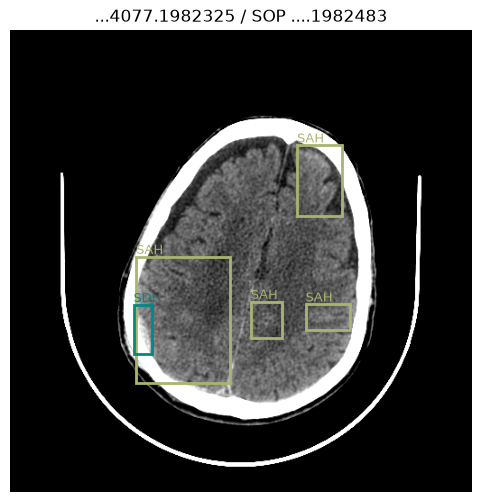

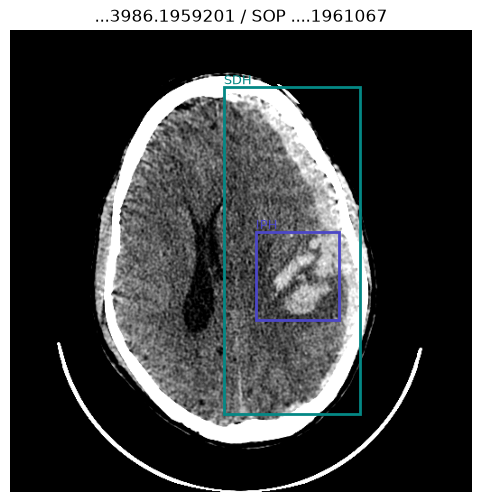

In [11]:
# SAH: 같은 슬라이스에 bbox가 여러 개로 쪼개져 그려진(세분화된) 사례
sah_multi = (
    bbox_df[bbox_df["abbr"] == "SAH"]
    .groupby(["StudyInstanceUID", "SOPInstanceUID"])
    .size()
    .rename("n_boxes")
    .reset_index()
    .sort_values("n_boxes", ascending=False)
)
print("SAH: 한 슬라이스에 bbox가 여러 개로 세분화된 사례 (상위 5개)")
display(sah_multi.head(5))

# SDH: 슬라이스당 bbox가 1개뿐인데 그 하나가 크게(면적 상위) 그려진 사례
sdh_single_large = (
    bbox_df[bbox_df["abbr"] == "SDH"]
    .groupby(["StudyInstanceUID", "SOPInstanceUID"])
    .agg(n_boxes=("area", "size"), area=("area", "max"))
    .reset_index()
)
sdh_single_large = sdh_single_large[sdh_single_large["n_boxes"] == 1].sort_values("area", ascending=False)
print("\nSDH: 슬라이스당 bbox 1개인데 크게(면적 상위) 그려진 사례 (상위 5개)")
display(sdh_single_large.head(5))

# 아래 5.3 오버레이 데모에서 사용할 대표 예시
sah_example = sah_multi.iloc[0]
sdh_example = sdh_single_large.iloc[0]
print(f"\nSAH 세분화 예시 -> study=...{sah_example['StudyInstanceUID'][-12:]}, "
      f"sop=...{sah_example['SOPInstanceUID'][-8:]}, n_boxes={sah_example['n_boxes']}")
print(f"SDH 대형 단일 bbox 예시 -> study=...{sdh_example['StudyInstanceUID'][-12:]}, "
      f"sop=...{sdh_example['SOPInstanceUID'][-8:]}, area={sdh_example['area']:.0f}")

for _, r in pd.concat([sah_multi.head(1), sdh_single_large.head(1)], ignore_index=True).iterrows():
    same_slice = df[
        (df["StudyInstanceUID"] == r["StudyInstanceUID"]) & (df["SOPInstanceUID"] == r["SOPInstanceUID"])
    ]
    show_bhx_sample(same_slice.iloc[0])

### 5.3 스캔 번호 / 슬라이스 번호 / 클래스 선택형 오버레이

`overlay(scan_no, slice_no, classes=...)` — `scan_no`는 `scan_uids`(study 목록, 1-based)에서의 순번, `slice_no`는 해당 scan의 series 안에서 InstanceNumber 오름차순 순번(1-based)이다. `classes`를 생략하면 그 슬라이스에 있는 모든 클래스를 표시하고, 색상은 기존 `class_names` / `class_colors` / `ABBR_COLOR_HEX`와 동일하게 통일한다.

선택 가능한 scan 수: 226 (scan_no = 1 ~ 226)


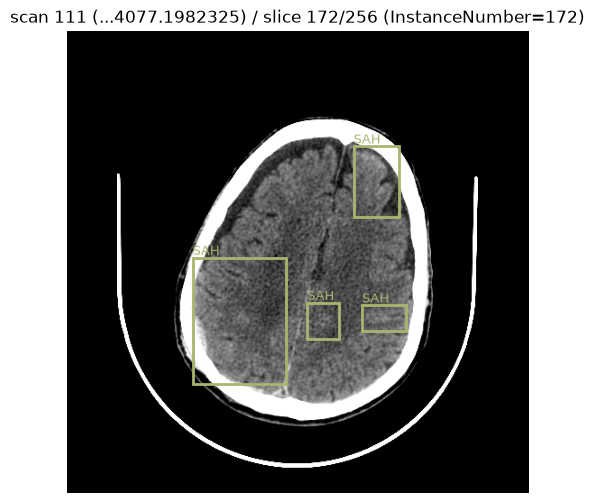

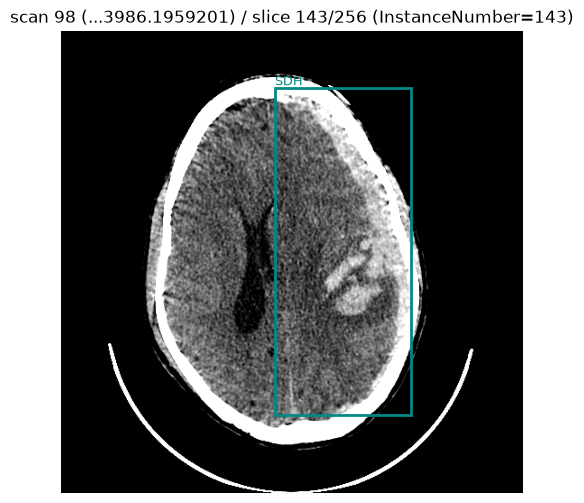

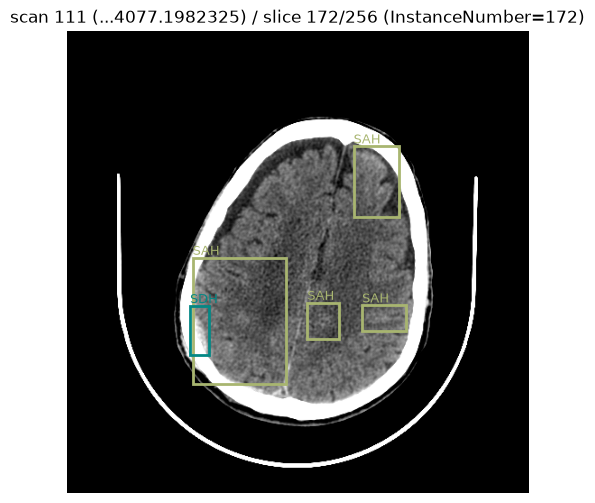

In [12]:
# scan_no(1-based) <-> StudyInstanceUID 매핑. annotation이 있는 study만 대상으로 함.
scan_uids = sorted(df["StudyInstanceUID"].unique())
print(f"선택 가능한 scan 수: {len(scan_uids)} (scan_no = 1 ~ {len(scan_uids)})")

_series_slices_cache: dict[tuple[str, str], list[tuple[int, str, Path]]] = {}


def list_series_slices(study_dir: Path, series_uid: str) -> list[tuple[int, str, Path]]:
    """study 폴더 안에서 특정 series에 속한 dcm들을 InstanceNumber 순으로 정렬해서 반환.
    (instance_number, sop_uid, path) 튜플 리스트. series당 1회만 스캔하고 캐시."""
    key = (str(study_dir), series_uid)
    if key in _series_slices_cache:
        return _series_slices_cache[key]

    slices = []
    for f in study_dir.rglob("*.dcm"):
        reader = sitk.ImageFileReader()
        reader.SetFileName(str(f))
        reader.ReadImageInformation()
        if reader.GetMetaData("0020|000e").strip() != series_uid:
            continue
        sop_uid = reader.GetMetaData("0008|0018").strip()
        instance_no = int(reader.GetMetaData("0020|0013").strip() or 0)
        slices.append((instance_no, sop_uid, f))

    slices.sort(key=lambda t: t[0])
    _series_slices_cache[key] = slices
    return slices


def overlay(scan_no: int, slice_no: int, classes: list[str] | None = None, series_uid: str | None = None):
    """scan 번호 + 슬라이스 번호 + 클래스 선택형 오버레이.

    scan_no    : 1-based, scan_uids 순번 (annotation 있는 study 중에서 선택)
    slice_no   : 1-based, 해당 scan에서 사용하는 series의 InstanceNumber 오름차순 순번
    classes    : 오버레이할 클래스 리스트, 예: ["SAH", "SDH"]. 생략하면 슬라이스의 모든 클래스 표시.
    series_uid : 생략하면 해당 scan에서 annotation이 가장 많은 series를 자동 선택
    """
    if not (1 <= scan_no <= len(scan_uids)):
        print(f"scan_no 범위 초과: 1~{len(scan_uids)} 사이 값을 입력하세요.")
        return
    study_uid = scan_uids[scan_no - 1]

    study_dir = study_uid_to_dir.get(study_uid)
    if study_dir is None:
        print("study를 찾을 수 없음:", study_uid)
        return

    if series_uid is None:
        series_counts = df[df["StudyInstanceUID"] == study_uid]["SeriesInstanceUID"].value_counts()
        series_uid = series_counts.index[0]

    slices = list_series_slices(study_dir, series_uid)
    if not slices:
        print("series를 찾을 수 없음:", series_uid)
        return
    if not (1 <= slice_no <= len(slices)):
        print(f"slice_no 범위 초과: 이 scan은 1~{len(slices)} 사이 값을 입력하세요.")
        return

    instance_no, sop_uid, dcm_path = slices[slice_no - 1]

    arr = sitk.GetArrayFromImage(sitk.ReadImage(str(dcm_path)))[0].astype(np.float32)
    windowed = apply_window(arr)

    same_slice = df[(df["StudyInstanceUID"] == study_uid) & (df["SOPInstanceUID"] == sop_uid)]
    if classes is not None:
        same_slice = same_slice[same_slice["abbr"].isin(classes)]

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(windowed, cmap="gray", vmin=0, vmax=1)
    if same_slice.empty:
        print("이 슬라이스/클래스 조합에는 annotation이 없음 (배경만 표시)")
    for _, r in same_slice.iterrows():
        bbox = parse_bbox(r["data"])
        color = ABBR_COLOR_HEX.get(r["abbr"], "lime")
        ax.add_patch(plt.Rectangle(
            (bbox["x"], bbox["y"]), bbox["width"], bbox["height"],
            fill=False, edgecolor=color, linewidth=2,
        ))
        ax.text(bbox["x"], bbox["y"] - 3, r["abbr"], color=color, fontsize=9)
    ax.set_title(
        f"scan {scan_no} (...{study_uid[-12:]}) / slice {slice_no}/{len(slices)} "
        f"(InstanceNumber={instance_no})"
    )
    ax.axis("off")
    plt.show()


def find_scan_slice_no(study_uid: str, sop_uid: str) -> tuple[int, int] | None:
    """StudyInstanceUID + SOPInstanceUID로 overlay()에 넣을 (scan_no, slice_no)를 역으로 찾는 헬퍼."""
    if study_uid not in scan_uids:
        return None
    scan_no = scan_uids.index(study_uid) + 1
    study_dir = study_uid_to_dir.get(study_uid)
    row = df[(df["StudyInstanceUID"] == study_uid) & (df["SOPInstanceUID"] == sop_uid)]
    if study_dir is None or row.empty:
        return None
    series_uid = row.iloc[0]["SeriesInstanceUID"]
    for i, (_, sop, _) in enumerate(list_series_slices(study_dir, series_uid), start=1):
        if sop == sop_uid:
            return scan_no, i
    return None


# 5.2에서 찾은 SAH 세분화 예시 / SDH 대형 단일 bbox 예시로 데모
sah_scan_no, sah_slice_no = find_scan_slice_no(sah_example["StudyInstanceUID"], sah_example["SOPInstanceUID"])
overlay(sah_scan_no, sah_slice_no, classes=["SAH"])

sdh_scan_no, sdh_slice_no = find_scan_slice_no(sdh_example["StudyInstanceUID"], sdh_example["SOPInstanceUID"])
overlay(sdh_scan_no, sdh_slice_no, classes=["SDH"])

# 클래스를 지정하지 않으면 해당 슬라이스의 전체 클래스를 함께 확인 가능
overlay(sah_scan_no, sah_slice_no)

## 6. Summary

selected_series(3번 CSV)를 기준으로 class imbalance, bbox size, downstream 학습용 추천 split을 정리한다.

### 6.1 Class imbalance 요약

In [13]:
class_summary = df["abbr"].value_counts().to_frame("count")
class_summary["ratio"] = (class_summary["count"] / class_summary["count"].sum()).round(3)
display(class_summary)

,count,ratio
abbr,,
SDH,7904,0.291
SAH,7596,0.279
IPH,5264,0.194
Chronic,3672,0.135
IVH,2219,0.082
EDH,548,0.020


### 6.2 클래스별 bbox 크기 요약

In [14]:
size_summary = bbox_df.groupby("abbr")[["width", "height", "area", "aspect_ratio"]].median().round(1)
display(size_summary.sort_values("area", ascending=False))

,width,height,area,aspect_ratio
abbr,,,,
Chronic,91.7,201.3,17806.9,0.4
SAH,66.9,94.6,6205.3,0.8
SDH,61.8,107.9,6152.6,0.5
IPH,65.4,84.9,5510.3,0.8
EDH,47.7,114.4,4302.3,0.5
IVH,36.5,39.0,1451.8,0.9
